In [1]:

# Import pandas for data manipulation
import pandas as pd

# Import LabelEncoder for label encoding
from sklearn.preprocessing import LabelEncoder


In [2]:
# Load the dataset
df = pd.read_csv("depression_data.csv")

# Display the first 5 rows
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'depression_data.csv'

In [23]:
# Display the data types of all columns
print(df.dtypes)

Name                             object
Age                               int64
Marital Status                   object
Education Level                  object
Number of Children                int64
Smoking Status                   object
Physical Activity Level          object
Employment Status                object
Income                          float64
Alcohol Consumption              object
Dietary Habits                   object
Sleep Patterns                   object
History of Mental Illness        object
History of Substance Abuse       object
Family History of Depression     object
Chronic Medical Conditions       object
dtype: object


In [24]:
# Check Categorical Columns
cat_cols = df.select_dtypes(include='object').columns

print(cat_cols)

Index(['Name', 'Marital Status', 'Education Level', 'Smoking Status',
       'Physical Activity Level', 'Employment Status', 'Alcohol Consumption',
       'Dietary Habits', 'Sleep Patterns', 'History of Mental Illness',
       'History of Substance Abuse', 'Family History of Depression',
       'Chronic Medical Conditions'],
      dtype='object')


In [25]:
# create original shape
original_shape = df.shape

In [26]:
# One-Hot Encode Multi-Category Columns
multi_cols = [
    "Marital Status",
    "Education Level",
    "Smoking Status",
    "Physical Activity Level",
    "Employment Status",
    "Alcohol Consumption",
    "Dietary Habits",
    "Sleep Patterns"
]

df = pd.get_dummies(
    df,
    columns=multi_cols,
    drop_first=True
)

In [27]:
# Label Encode Binary Columns
le = LabelEncoder()

binary_cols = [
    "History of Substance Abuse",
    "Family History of Depression",
    "Chronic Medical Conditions",
    "History of Mental Illness"
]

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

In [28]:
# check result
df.head()

,Name,Age,Number of Children,Income,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions,Marital Status_Married,Marital Status_Single,...,Smoking Status_Non-smoker,Physical Activity Level_Moderate,Physical Activity Level_Sedentary,Employment Status_Unemployed,Alcohol Consumption_Low,Alcohol Consumption_Moderate,Dietary Habits_Moderate,Dietary Habits_Unhealthy,Sleep Patterns_Good,Sleep Patterns_Poor
0,Christine Barker,31,2,26265.67,1,0,1,1,True,False,...,True,False,False,True,False,True,True,False,False,False
1,Jacqueline Lewis,55,1,42710.36,1,0,0,1,True,False,...,True,False,True,False,False,False,False,True,False,False
2,Shannon Church,78,1,125332.79,0,0,1,0,False,False,...,True,False,True,False,True,False,False,True,True,False
3,Charles Jordan,58,3,9992.78,0,0,0,0,False,False,...,True,True,False,True,False,True,True,False,False,True
4,Michael Rich,18,0,8595.08,1,0,1,1,False,True,...,True,False,True,True,True,False,True,False,False,False


In [29]:
print("Before:", original_shape)

Before: (413768, 16)


In [30]:
print("After:", df.shape)

After: (413768, 26)


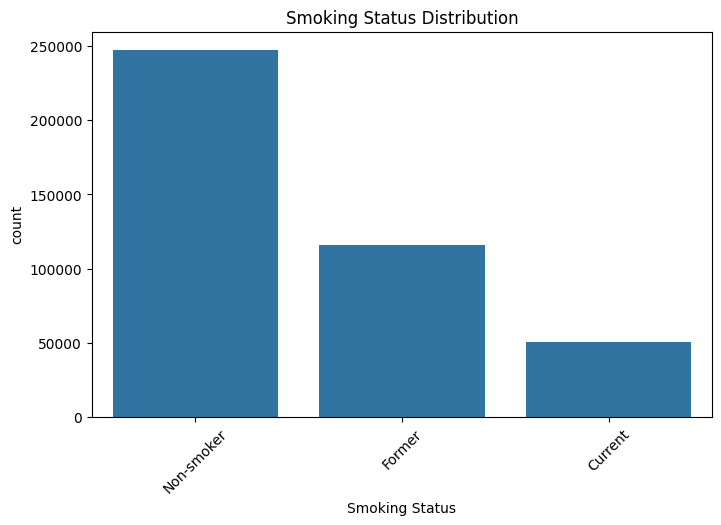

In [31]:
# EDA Graph - Smoking Status Count Plot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(
    x="Smoking Status",
    data=pd.read_csv("depression_data.csv")
)

plt.title("Smoking Status Distribution")

plt.xticks(rotation=45)

plt.show()

In [34]:
df.to_csv("depression_data_processed.csv", index=False)